In [931]:
import torch
from networkx.algorithms import wiener
from torch import nn
import matplotlib.pyplot as plt
from torch.special import modified_bessel_i1

In [932]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).reshape(-1, 1)

y = bias + weight * X

In [933]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


In [934]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [935]:
def plot_prediction(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, pred=None):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, s=10, c='b', label="Training Data")
    plt.scatter(test_data, test_labels, s=10, c='g', label="Testing Data")
    plt.grid(True)
    if pred is not None:
        plt.scatter(test_data, pred, s=10, c='r', label="Prediction")

    plt.legend()

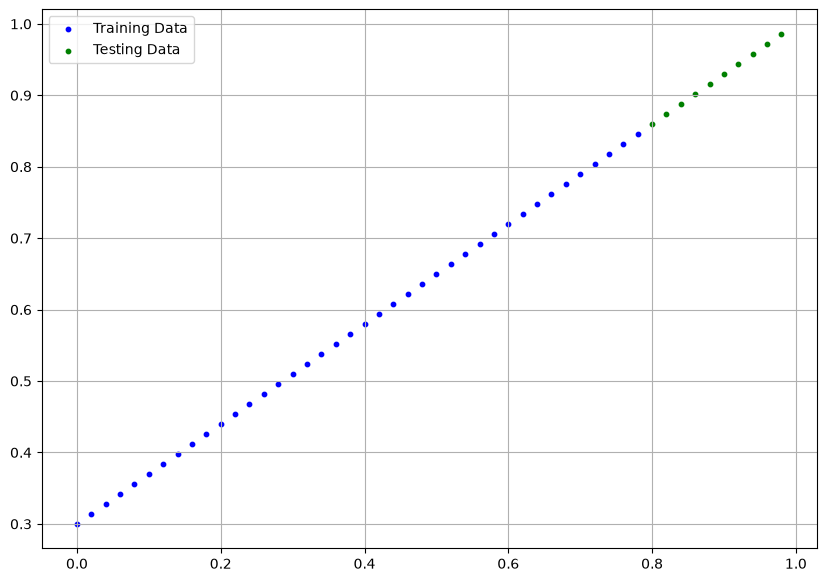

In [936]:
plot_prediction()

Our Model:
* Start with random parameters (weight & bias)
* Look at training data and adjust the random parameters to better represent (get closer) the ideal values (the weights and bias we used to create our data)

It uses:
* Gradient Descent
* backpropogation

In [937]:
# Linear Regression Model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.bias + self.weight * x

# PyTorch model building essentials

- **`torch.nn`**
  Contains all the building blocks for computational graphs (a neural network can be considered a computational graph).

- **`torch.nn.Parameter`**
  Defines what parameters our model should try and learn. Often a PyTorch layer from `torch.nn` will set these for us.

- **`torch.nn.Module`**
  The base class for all neural network modules. If you subclass it, you should override `forward()`.

- **`torch.optim`**
  This is where the optimizers in PyTorch live. They help with gradient descent.

- **`def forward()`**
  All `nn.Module` subclasses require you to override `forward()`. This method defines what happens in the forward computation.

### Making predictions using `torch.inference_mode()` or `torch.no_grad()`
- To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`
- When we pass data through our model, it's going to run it through the `forward`() method

In [938]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

with torch.inference_mode():
    y_pred = model_0(X_test)

y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [939]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

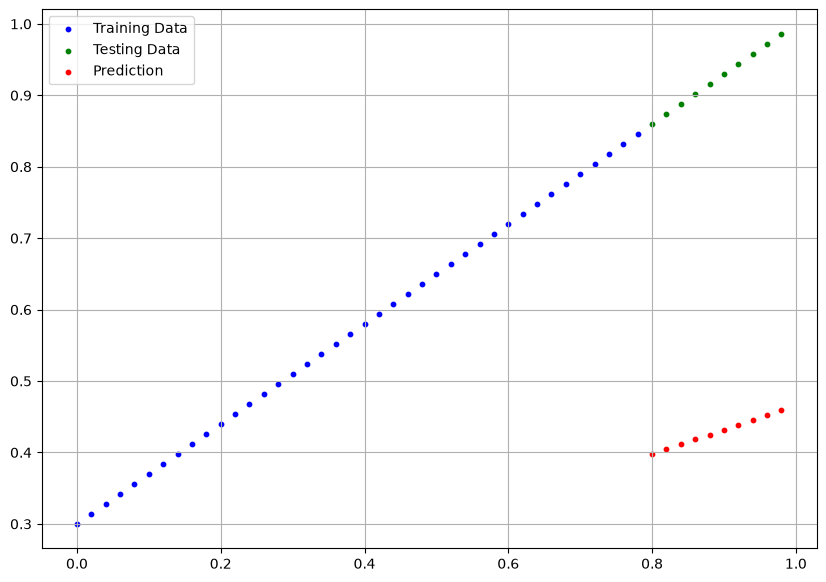

In [940]:
plot_prediction(pred=y_pred)

## 3. Train model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters.
Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your model's predictions are is to use a **loss function**.

- **Note:** Loss function may also be called *cost function* or *criterion* in different areas. For our case, we're going to refer to it as a loss function.

Things we need to train:

- **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
- **Optimizer:** Takes into account the loss of a model and adjust the model's parameters (weight and bias in our case) to improve the loss function.

And specifically for PyTorch, we need:
* A training loop
* A testing loop

### Set up Loss function and Optimizer

In [941]:
# Set up a loss function

loss_fun = nn.L1Loss()

# Set up an optimizer (Stochastic gradient descent)

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)


### Set up Training and testing loop
Steps for training loop:
1. Loop through the data
2. Forward pass (data moving through `forward()`)
3. Calculate the loss (compare the forward pass predictions to ground truth labels)
4. Optimizer zero grad
5. Loss backward - move backward through the network to calculate the gradients of each of the parameters of our model w.r.t. lose (**Backpropagation**)
6. Optimizer step - adjust parameters (**Gradient Descent**)

In [942]:
# An epoch is one loop through the data

torch.manual_seed(42)
epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []
# Training
# Step 1: loop through data
for epoch in range(epochs):
    model_0.train()  # Set all parameters that require gradient descent to require gradient
    # 2. Forward pass
    y_pred_train = model_0(X_train)
    # 3. Calculate Loss
    loss = loss_fun(y_pred_train, y_train)
    # print(f"Loss: {loss}")
    # 4. Optimizer
    optimizer.zero_grad()
    # 5. Backpropagation
    loss.backward()
    # 6. Optimizer step
    optimizer.step()

    # Testing
    model_0.eval()  # turns off different settings that are not needed in testing and evaluation
    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fun(test_pred, y_test)

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
    # print(model_0.state_dict())

In [943]:
import numpy as np

np.array(torch.tensor(loss_values).cpu().numpy())

array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
       0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
       0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
       0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
      dtype=float32)

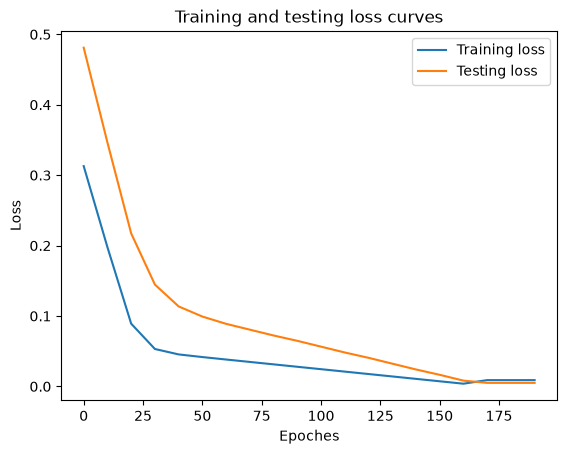

In [944]:
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Training loss")
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).numpy()), label="Testing loss")
plt.title("Training and testing loss curves")
plt.xlabel("Epoches")
plt.ylabel("Loss")
plt.legend();

In [945]:
with torch.inference_mode():
    y_pred_new = model_0(X_test)

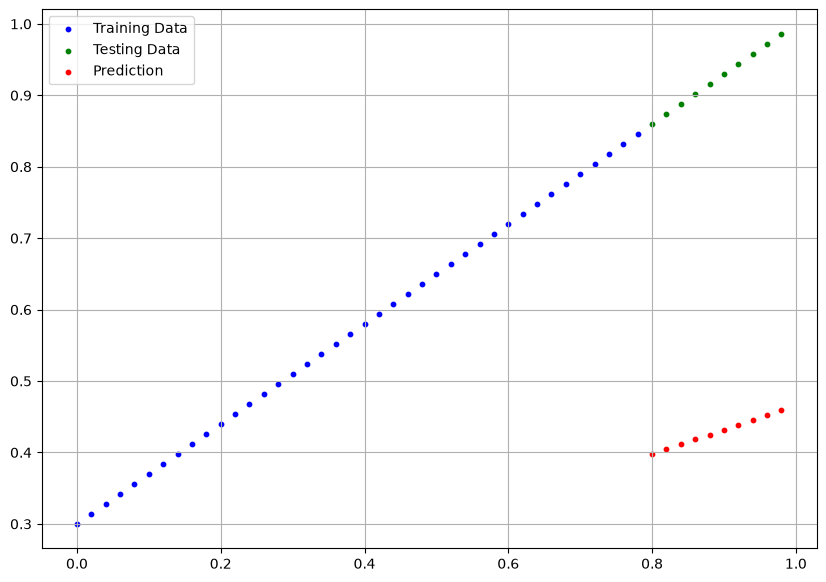

In [946]:
plot_prediction(pred=y_pred)

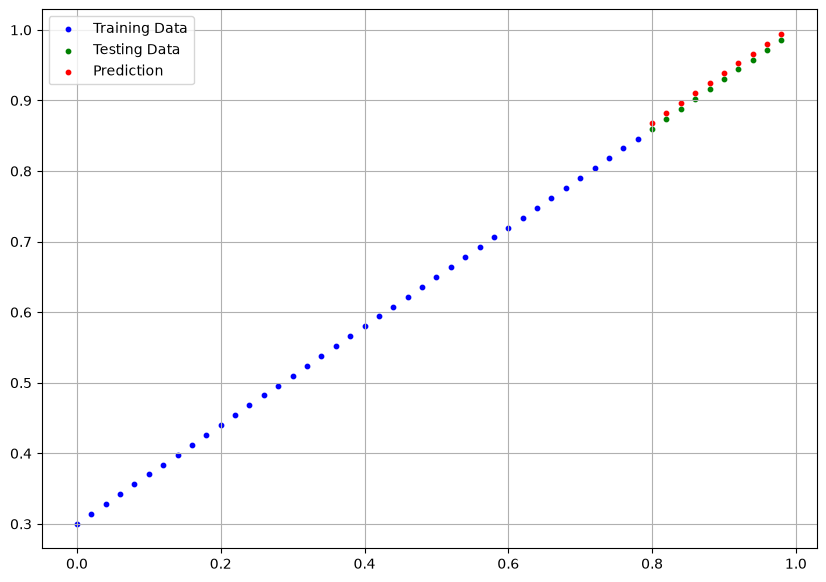

In [947]:
plot_prediction(pred=y_pred_new)

In [948]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

### Saving a model in PyTorch

There are three main methods you should know about for saving and loading models in PyTorch.

1. `torch.save()` - allows you to save a PyTorch object in Python's pickle format
2. `torch.load()` - allows you to load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - this allows you to load a model's saved state dictionary

In [949]:
from pathlib import Path

# Create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
#create mode save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
# Save the model
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

### Loading model's state_dict()

In [950]:
loaded_model_0 = LinearRegressionModel()
loaded_model_0.state_dict()  # Random parameters

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [951]:
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [952]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [953]:
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)


In [954]:
y_pred_new == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

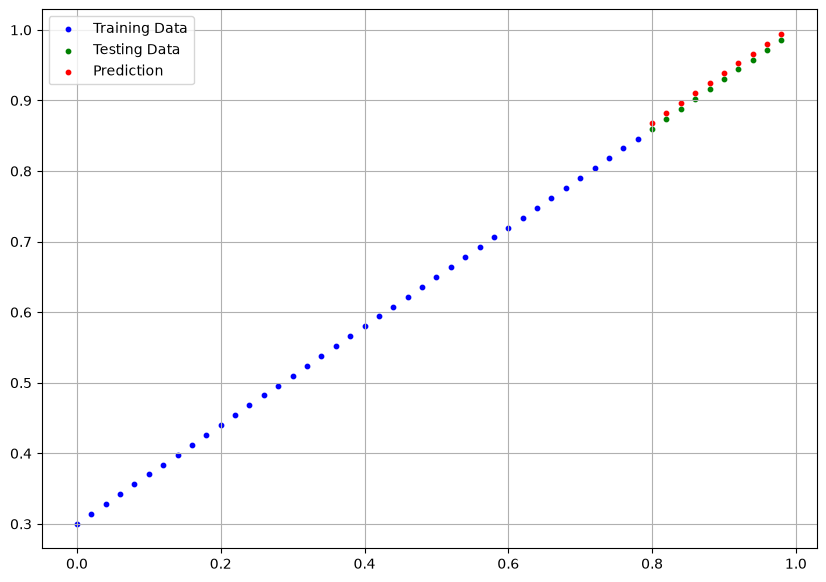

In [955]:
plot_prediction(pred=loaded_model_preds)

### Putting all the things we have done in this notebook in one place, for better practice and recall

In [956]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [957]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [968]:
weight = 0.5
bias = 0.5

X = torch.arange(1, 1000, 7.69)
y = bias + weight * X

130

In [959]:
split = int(0.7 * len(X))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

In [960]:
len(X_train), len(y_train), len(X_test), len(y_test)

(91, 91, 39, 39)

In [961]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(1), requires_grad=True)

        self.bias = nn.Parameter(torch.randn(1), requires_grad=True)

    def forward(self, x):
        return self.weight * x + self.bias

In [962]:
def plot_prediction(predictions=None):
    plt.figure(figsize=(10, 7))
    plt.grid(True)

    plt.scatter(X_train, y_train, c='blue', label="Training Data")

    plt.scatter(X_test, y_test, c='green', label="Testing Data")

    if predictions is not None:
        plt.scatter(X_test, predictions, c='red', label="Predictions")

    plt.legend()
    plt.show()

In [963]:
torch.manual_seed(42)

model_1 = LinearRegression()

list(model_1.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [964]:
loss_fun = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.00001)

In [965]:
num_epoch = 100

for epoch in range(num_epoch):

    # Training
    model_1.train()
    y_pred = model_1(X_train)

    train_loss = loss_fun(y_pred, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Testing
    model_1.eval()

    with torch.inference_mode():
        y_pred_test = model_1(X_test)
        test_loss = loss_fun(y_pred_test, y_test)

    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Test Loss: {test_loss:.4f}"
        )

        print(
            f"Weight: {model_1.weight.item():.4f} | "
            f"Bias: {model_1.bias.item():.4f}"
        )

Epoch: 0 | Train Loss: 57.0478 | Test Loss: 135.7389
Weight: 0.3402 | Bias: 0.1288


In [966]:
model_1.state_dict()

OrderedDict([('weight', tensor([0.5037])), ('bias', tensor([0.1294]))])

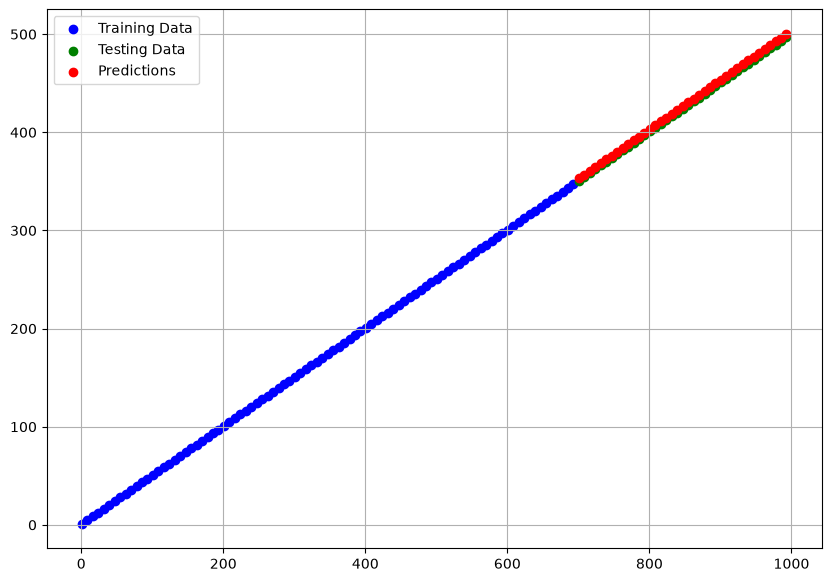

In [967]:
plot_prediction(y_pred_test)